# Spatially-Explicit Uncertainty of the Satellite-Air Temperature Discrepancy (ΔT) across the Urban-Rural Gradient in Flanders

**A GeoConformal mini-study** | by Zefanya Yedija Hamonangan

This study applies **GeoConformal prediction** (Lou, Luo & Meng, 2025), a
model-agnostic, spatially-explicit uncertainty-quantification framework, to the
discrepancy between satellite land surface temperature and reanalysis air
temperature, ΔT = LST - T2m, across Flanders, Belgium. An intentionally *aspatial*
Random Forest predicts ΔT from surface properties (NDVI, land use); GeoConformal
then wraps it to produce spatially-varying prediction intervals, so that geography
enters only through distance-weighted calibration. The aim is not predictive
accuracy but **reliability mapping**: showing where ΔT predictions can be trusted,
validating coverage, and probing what such a map actually represents.

**Key result.**  
GeoConformal achieves valid +- 90 % coverage and redistributes
interval width across space (4.5-9.8 °C) while ordinary conformal prediction is
flat. Critically, a tempting physical reading of the resulting west-east gradient
is shown to be an artefact of the method's reliance on calibration-residual tails, a caution to interpreting spatial uncertainty maps.

**Pipeline:**
- Phase 1 data preparation
- Phase 2 aspatial modeling
- Phase 3 GeoConformal uncertainty quantification.

# Phase 1: Data Preparation
**Spatially-explicit uncertainty of satellite-air temperature discrepancy (ΔT) across the urban-rural gradient in Flanders**

This notebook prepares an analysis-ready dataset for a GeoConformal experiment.
It assumes the raw data has already been retrieved (see retrieval notebook) and
stored in Google Drive. Running this notebook end-to-end reproduces all
preprocessing and analysis.

**Inputs (already on Drive):**
- `flanders_LST_NDVI_DEM_2021warm_v2_fixed.tif` : 3 bands (LST °C, NDVI, DEM m), EPSG:3035, 100 m, warm-season 2021 morning composite
- `t2m_flanders_warm2021_clean.nc` : ERA5-Land 2 m air temperature (°C), 9 km, warm-season 09:00 UTC mean
- Land-cover raster (fine-scale, retrieved from www.vlaanderen.be)

**Target variable:** ΔT = LST - T2m (satellite skin temperature - macroclimate air temperature)

In [25]:
!pip -q install rioxarray rasterio xarray netCDF4

In [26]:
# --- Environment & paths ---

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
from rasterio.enums import Resampling
from google.colab import drive

drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Mini Project'
RASTER_PATH  = f'{BASE}/flanders_LST_NDVI_DEM_2021warm_v2_fixed.tif'   # NDVI-fixed version
T2M_PATH     = f'{BASE}/t2m_flanders_warm2021_clean.nc'
CRS_METRIC   = 'EPSG:3035'   # ETRS-LAEA, metric, required so distances are in metres

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# --- Load 3-band raster: LST, NDVI, DEM. This grid is the TEMPLATE everything aligns to. ---
stack = rioxarray.open_rasterio(RASTER_PATH, masked=True)   # masked=True -> nodata becomes NaN
# Band order from the GEE export: 1=LST, 2=NDVI, 3=DEM
lst  = stack.sel(band=1).rename('LST')
ndvi = stack.sel(band=2).rename('NDVI')
dem  = stack.sel(band=3).rename('DEM')

print('Grid CRS :', stack.rio.crs)
print('Grid shape (y, x):', lst.shape)
print('Pixel size :', stack.rio.resolution(), '(metres)')
for name, da in [('LST', lst), ('NDVI', ndvi), ('DEM', dem)]:
    print(f'{name:4s}  min {float(da.min()):8.3f}   max {float(da.max()):8.3f}   mean {float(da.mean()):8.3f}')

Grid CRS : EPSG:3035
Grid shape (y, x): (919, 2311)
Pixel size : (100.0, -100.0) (metres)
LST   min    5.947   max   62.843   mean   28.547
NDVI  min   -1.000   max    1.000   mean    0.633
DEM   min  -23.309   max  181.565   mean   28.970


In [28]:
# --- Load ERA5 T2m, give it a CRS, and resample onto the LST/NDVI/DEM grid ---
t2m = xr.open_dataarray(T2M_PATH)
t2m = t2m.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude')
t2m = t2m.rio.write_crs('EPSG:4326')   # ERA5 native CRS (lat/lon)

# Resample onto the template grid using NEAREST (not bilinear).
# Rationale: ERA5 is 9 km. Nearest preserves the block-constant structure
# each coarse cell keeps one value across the fine grid, rather than inventing smooth
# gradients. This makes the satellite–reanalysis support mismatch explicit
t2m_grid = t2m.rio.reproject_match(lst, resampling=Resampling.nearest).rename('T2m')

print('T2m aligned shape:', t2m_grid.shape, '(matches LST:', lst.shape == t2m_grid.shape, ')')
print(f'T2m   min {float(t2m_grid.min()):8.3f}   max {float(t2m_grid.max()):8.3f}   mean {float(t2m_grid.mean()):8.3f}')

T2m aligned shape: (919, 2311) (matches LST: True )
T2m   min   13.568   max   16.029   mean   15.839


In [29]:
# --- Target variable: ΔT = LST - T2m ---
delta = (lst - t2m_grid).rename('dT')
delta = delta.rio.write_crs(CRS_METRIC)   # re-stamp CRS

print(f'ΔT   min {float(delta.min()):8.3f}   max {float(delta.max()):8.3f}   mean {float(delta.mean()):8.3f}')

delta.rio.to_raster(f'{BASE}/dT_flanders_warm2021.tif')
print('Saved: dT_flanders_warm2021.tif')

ΔT   min   -9.602   max   47.179   mean   12.884
Saved: dT_flanders_warm2021.tif


In [30]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import rioxarray

LANDUSE_PATH = f'{BASE}/LandUse/lu_landgebruik_vlaa_2022_v3.tif'
QML_PATH = f'{BASE}/LandUse/lu_landgebruik_vlaa_2022_v3.qml'

# Translation mapping from Dutch (QML source) to English
dutch_to_english = {
    "Huizen en tuinen": "Houses and gardens",
    "Industrie": "Industry",
    "Commerciële doeleinden": "Commercial purposes",
    "Diensten": "Services / Public facilities",
    "Transportinfrastructuur": "Transport infrastructure",
    "Recreatie": "Recreation and leisure",
    "Landbouwgebouwen en -infrastructuur": "Agricultural buildings & infrastructure",
    "Overige bebouwde terreinen": "Other built-up areas",
    "Overige onbebouwde terreinen": "Other non-built-up areas",
    "Actieve groeves": "Active quarries",
    "Luchthavens": "Airports",
    "Bos": "Forest",
    "Akker": "Arable land / Cropland",
    "Grasland in landbouwgebruik": "Grassland in agricultural use",
    "Struikgewas": "Shrubland / Scrub",
    "Braakliggend en duinen": "Fallow land and dunes",
    "Water": "Water bodies",
    "Moeras": "Marshes / Wetlands",
    "Overige graslanden": "Other grasslands"
}

# 2. READ & COUNT RASTER PIXELS
# ==================================================================
print("==================================================")
# STEP I: Read land-use raster spatial metadata
lc = rioxarray.open_rasterio(LANDUSE_PATH, masked=True).sel(band=1)
print('Land-cover CRS           :', lc.rio.crs)
print('Land-cover pixel size    :', lc.rio.resolution())

# STEP II: Calculate unique pixel frequency distribution (excluding NaN values)
vals, counts = np.unique(lc.values[~np.isnan(lc.values)], return_counts=True)
pixel_dict = dict(zip(vals, counts))


# 3. PARSE QML & TRANSLATE TO ENGLISH LEGEND
# =====================================================================
print("\n==================================================")
print("   LAND USE LEGEND & PIXEL COUNT (ENGLISH VERSION) ")
print("==================================================")

try:
    tree = ET.parse(QML_PATH)
    root = tree.getroot()
    found = False

    # Loop to extract color palette, class values, and original labels from QML
    for entry in root.iter('paletteEntry'):
        val_raw = entry.get('value')
        val_int = int(float(val_raw))
        label_dutch = entry.get('label')
        color = entry.get('color')

        # Translation process: Get from dictionary if available, fallback to original if not
        label_english = dutch_to_english.get(label_dutch, label_dutch)

        # Retrieve the pixel count from the raster dictionary (default to 0 if class is missing)
        p_count = pixel_dict.get(val_int, 0)

        # Print consolidated output with clean table formatting
        print(f"Class {val_int:>2} : {label_english:<42} | Pixels: {p_count:<10} | Color: {color}")
        found = True

    if not found:
        print("⚠️ 'paletteEntry' tag not found within the QML file structure.")

except FileNotFoundError as e:
    print(f"❌ File not found! Please check the following paths:\n   Raster: {LANDUSE_PATH}\n   QML: {QML_PATH}")
except Exception as e:
    print(f"❌ An error occurred during execution: {e}")

print("==================================================")

Land-cover CRS           : EPSG:31370
Land-cover pixel size    : (10.0, -10.0)

   LAND USE LEGEND & PIXEL COUNT (ENGLISH VERSION) 
Class  1 : Houses and gardens                         | Pixels: 17315054   | Color: #ff0000
Class  2 : Industry                                   | Pixels: 4161326    | Color: #8400a8
Class  3 : Commercial purposes                        | Pixels: 711449     | Color: #ff00c5
Class  4 : Services / Public facilities               | Pixels: 1834066    | Color: #002673
Class  5 : Transport infrastructure                   | Pixels: 8358910    | Color: #686868
Class  6 : Recreation and leisure                     | Pixels: 4016405    | Color: #ffaa00
Class  7 : Agricultural buildings & infrastructure    | Pixels: 1059810    | Color: #a87000
Class  8 : Other built-up areas                       | Pixels: 2648955    | Color: #cccccc
Class  9 : Other non-built-up areas                   | Pixels: 3812319    | Color: #828282
Class 10 : Active quarries              

In [31]:
# --- Reclassify 19-class Landgebruik Vlaanderen 2022 -> 5 physically-motivated classes ---
# Verified against the official QML legend (parsed in the previous cell).
# Grouping is by surface behaviour w.r.t. ΔT = LST - T2m, not administrative label.
#   1 = Urban / sealed        (houses, industry, commercial, services, transport, other built-up, airports)
#   2 = Agriculture           (agri buildings, arable, agricultural grassland)
#   3 = Forest / natural veg  (forest, shrub, fallow/dunes, marsh, other grassland)
#   4 = Water
#   5 = Other / mixed         (recreation, other non-built, quarries)
REMAP = {
    1:1, 2:1, 3:1, 4:1, 5:1, 8:1, 11:1,     # Urban / sealed
    7:2, 13:2, 14:2,                         # Agriculture
    12:3, 15:3, 16:3, 18:3, 19:3,            # Forest / natural vegetation
    17:4,                                    # Water
    6:5, 9:5, 10:5,                          # Other / mixed
}
CLASS_NAMES = {1:'Urban', 2:'Agriculture', 3:'Forest/natural', 4:'Water', 5:'Other'}

src = lc.values.astype('float32')
out = np.full_like(src, np.nan)
for orig, coarse in REMAP.items():
    out[src == orig] = coarse
lc_coarse = lc.copy(data=out)

# Align onto the template grid: reproject 31370 -> 3035, resample 10 m -> 100 m.
# NEAREST is mandatory: land use is categorical, so interpolation would invent meaningless
# fractional classes. At 100 m each cell takes the class of its nearest 10 m source pixel.
from rasterio.enums import Resampling
lc_grid = lc_coarse.rio.reproject_match(lst, resampling=Resampling.nearest).rename('landuse')

print('Land-use aligned shape:', lc_grid.shape, '(matches LST:', lst.shape == lc_grid.shape, ')')
v, c = np.unique(lc_grid.values[~np.isnan(lc_grid.values)], return_counts=True)
tot = c.sum()
print('Coarse class distribution on the 100 m grid:')
for vv, cc in zip(v, c):
    print(f'  {int(vv)} {CLASS_NAMES[int(vv)]:<15} {cc:>8} px  ({100*cc/tot:4.1f}%)')

Land-use aligned shape: (919, 2311) (matches LST: True )
Coarse class distribution on the 100 m grid:
  1 Urban             351330 px  (25.8%)
  2 Agriculture       660647 px  (48.5%)
  3 Forest/natural    238102 px  (17.5%)
  4 Water              32054 px  ( 2.4%)
  5 Other              79546 px  ( 5.8%)


In [32]:
# --- Build a single aligned cube, then sample 1000 points with deliberate urban bias ---
import numpy as np, pandas as pd, xarray as xr

rng = np.random.default_rng(42)   # reproducible

# 1. Stack all layers on the shared grid into one Dataset (so a pixel = one row with all vars)
# FIX: Drop the conflicting 'band' coordinate from all DataArrays before merging
cube = xr.Dataset({
    'dT':      delta.drop_vars('band', errors='ignore'),
    'NDVI':    ndvi.drop_vars('band', errors='ignore'),
    'DEM':     dem.drop_vars('band', errors='ignore'),
    'landuse': lc_grid.drop_vars('band', errors='ignore'),
})

# 2. Flatten to a long table of every pixel, with its projected coordinates (metres, EPSG:3035)
df_all = cube.to_dataframe().reset_index()
df_all = df_all.rename(columns={'x': 'x', 'y': 'y'})[['x', 'y', 'dT', 'NDVI', 'DEM', 'landuse']]

# 3. AND-logic: keep only pixels where EVERY variable exists (no NaN in any column)
before = len(df_all)
df_all = df_all.dropna().reset_index(drop=True)
print(f'Complete-case pixels: {len(df_all):,} of {before:,} '
      f'({100*len(df_all)/before:.1f}% retained after AND-masking)')

# 4. URBAN-BIASED sampling weights
#    Dense in cities, sparse in countryside -> uneven coverage -> spatially-varying reliability.
#    Weight by class: Urban most likely to be sampled, rural least.
class_weight = {1: 6.0,   # Urban  - oversample heavily
                2: 1.0,   # Agriculture - the sparse majority
                3: 1.5,   # Forest/natural
                4: 2.0,   # Water
                5: 1.5}   # Other

# FIX: Added .fillna() so classes outside 1-5 (like 12, 13, 19) don't become NaN and crash the sampler
w = df_all['landuse'].map(class_weight).fillna(1.0).to_numpy()
w = w / w.sum()

N = 1000
idx = rng.choice(len(df_all), size=N, replace=False, p=w)
df = df_all.iloc[idx].reset_index(drop=True)

# 5. Report the realised sampling vs the landscape, to PROVE the bias is intentional
print(f'\nSampled {len(df)} points.')
print('Class share — sampled vs full landscape:')
land_share = df_all['landuse'].value_counts(normalize=True).sort_index()
samp_share = df['landuse'].value_counts(normalize=True).sort_index()
names = {1:'Urban', 2:'Agriculture', 3:'Forest/natural', 4:'Water', 5:'Other'}

for k in sorted(names):
    print(f'  {names[k]:<15} landscape {100*land_share.get(k,0):4.1f}%   sampled {100*samp_share.get(k,0):4.1f}%')

df.to_csv(f'{BASE}/geoconformal_points.csv', index=False)
print('\nSaved: geoconformal_points.csv')
df.head()

Complete-case pixels: 1,337,207 of 2,123,809 (63.0% retained after AND-masking)

Sampled 1000 points.
Class share — sampled vs full landscape:
  Urban           landscape 26.0%   sampled 66.6%
  Agriculture     landscape 48.3%   sampled 17.2%
  Forest/natural  landscape 17.5%   sampled 12.2%
  Water           landscape  2.3%   sampled  1.1%
  Other           landscape  5.9%   sampled  2.9%

Saved: geoconformal_points.csv


,x,y,dT,NDVI,DEM,landuse
0,3971050.0,3146450.0,22.411335,0.412167,25.321594,1.0
1,3915150.0,3087950.0,8.369797,0.827990,35.464058,2.0
2,3987150.0,3106950.0,13.314854,0.684083,27.730438,2.0
3,3957050.0,3144750.0,17.567360,0.566078,20.063618,1.0
4,3838850.0,3114350.0,21.290649,0.330192,20.092171,1.0


In [33]:
# SANITY CHECK — alignment, CRS, grid, ranges, sampling integrity
# ============================================================
print("=== 1. CRS of every layer ===")
for name, da in [('LST', lst), ('NDVI', ndvi), ('DEM', dem),
                 ('T2m', t2m_grid), ('dT', delta), ('landuse', lc_grid)]:
    print(f'  {name:8s}: {da.rio.crs}')

print("\n=== 2. Grid shape & resolution (must be identical) ===")
for name, da in [('LST', lst), ('NDVI', ndvi), ('DEM', dem),
                 ('T2m', t2m_grid), ('dT', delta), ('landuse', lc_grid)]:
    print(f'  {name:8s}: shape {tuple(da.shape)}  res {da.rio.resolution()}')

print("\n=== 3. Do coordinates line up exactly? (compare x/y arrays to LST) ===")
import numpy as np
for name, da in [('NDVI', ndvi), ('DEM', dem), ('T2m', t2m_grid),
                 ('dT', delta), ('landuse', lc_grid)]:
    same_x = np.allclose(da['x'].values, lst['x'].values)
    same_y = np.allclose(da['y'].values, lst['y'].values)
    print(f'  {name:8s}: x match {same_x}   y match {same_y}')

print("\n=== 4. T2m coarseness check (should be ~56 unique values, not smooth) ===")
print(f'  unique T2m values on 100 m grid: {np.unique(t2m_grid.values[~np.isnan(t2m_grid.values)]).size}')

print("\n=== 5. Final dataframe integrity ===")
print(f'  rows: {len(df)}   any NaN? {df.isna().any().any()}')
print(f'  duplicate points? {df.duplicated(subset=["x","y"]).any()}')
print(f'  x range: {df.x.min():.0f} .. {df.x.max():.0f}')
print(f'  y range: {df.y.min():.0f} .. {df.y.max():.0f}')
print(f'  dT range: {df.dT.min():.2f} .. {df.dT.max():.2f}')
print(f'  landuse classes present: {sorted(df.landuse.unique())}')

=== 1. CRS of every layer ===
  LST     : EPSG:3035
  NDVI    : EPSG:3035
  DEM     : EPSG:3035
  T2m     : EPSG:3035
  dT      : EPSG:3035
  landuse : EPSG:3035

=== 2. Grid shape & resolution (must be identical) ===
  LST     : shape (919, 2311)  res (100.0, -100.0)
  NDVI    : shape (919, 2311)  res (100.0, -100.0)
  DEM     : shape (919, 2311)  res (100.0, -100.0)
  T2m     : shape (919, 2311)  res (100.0, -100.0)
  dT      : shape (919, 2311)  res (100.0, -100.0)
  landuse : shape (919, 2311)  res (100.0, -100.0)

=== 3. Do coordinates line up exactly? (compare x/y arrays to LST) ===
  NDVI    : x match True   y match True
  DEM     : x match True   y match True
  T2m     : x match True   y match True
  dT      : x match True   y match True
  landuse : x match True   y match True

=== 4. T2m coarseness check (should be ~56 unique values, not smooth) ===
  unique T2m values on 100 m grid: 56

=== 5. Final dataframe integrity ===
  rows: 1000   any NaN? False
  duplicate points? Fal

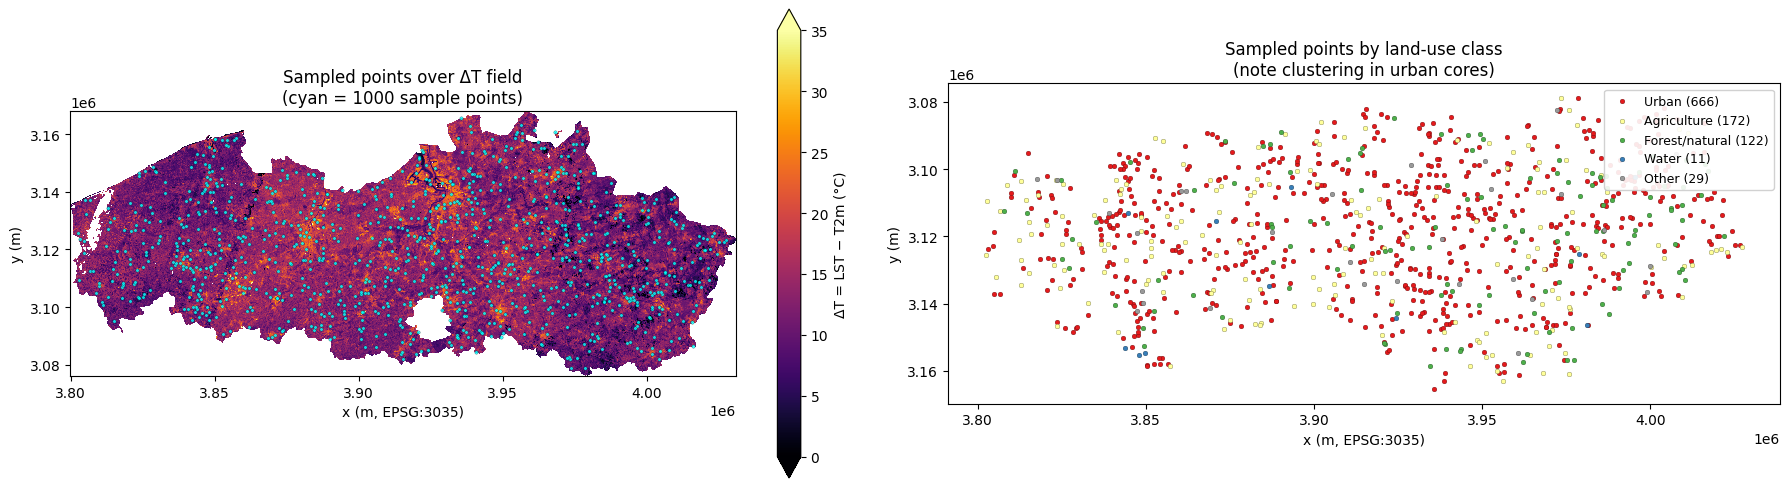

Saved: sample_distribution.png


In [34]:
# VISUAL CHECK — where the 1000 sampled points fall
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

names  = {1:'Urban', 2:'Agriculture', 3:'Forest/natural', 4:'Water', 5:'Other'}
colors = {1:'#e41a1c', 2:'#ffff99', 3:'#4daf4a', 4:'#377eb8', 5:'#999999'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT: ΔT background (full grid) + sampled points on top ---
ax = axes[0]
delta.plot.imshow(ax=ax, cmap='inferno', vmin=0, vmax=35,
                  cbar_kwargs={'label': 'ΔT = LST − T2m (°C)', 'shrink': 0.7})
ax.scatter(df.x, df.y, s=6, c='cyan', edgecolor='black', linewidth=0.2, alpha=0.8)
ax.set_title('Sampled points over ΔT field\n(cyan = 1000 sample points)')
ax.set_xlabel('x (m, EPSG:3035)'); ax.set_ylabel('y (m)')
ax.set_aspect('equal')

# --- RIGHT: points colored by land-use class, to see the urban clustering ---
ax = axes[1]
# faint full-extent backdrop so the empty rural areas are visible
ax.scatter(df.x, df.y, s=0)  # set extent
for k in sorted(names):
    sub = df[df.landuse == k]
    ax.scatter(sub.x, sub.y, s=12, c=colors[k], edgecolor='black',
               linewidth=0.15, label=f'{names[k]} ({len(sub)})')
ax.set_title('Sampled points by land-use class\n(note clustering in urban cores)')
ax.set_xlabel('x (m, EPSG:3035)'); ax.set_ylabel('y (m)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.invert_yaxis()  # match imshow orientation

plt.tight_layout()
plt.savefig(f'{BASE}/sample_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_distribution.png')

**Phase 1 outcome.**  
All layers are aligned to a common 100 m EPSG:3035 grid and
verified (identical shape, matching coordinates, T2m correctly coarse at 56 unique
values). 1,000 points were sampled with deliberate urban bias, Urban makes up
66.6 % of the sample but only 26 % of the landscape, producing the uneven spatial
coverage that makes GeoConformal's distance weighting meaningful. The analysis-ready
table is saved as `geoconformal_points.csv`.

# Phase 2: Modeling

Train a baseline model to predict ΔT = LST - T2m from physically-motivated
predictors (NDVI, elevation, land-use class). This model is intentionally
**aspatial**: coordinates are *not* used as features. Geography enters only
later, through GeoConformal's distance weighting (Phase 3). Keeping the base
model aspatial lets us isolate what spatial reliability weighting actually adds.

Data is split three ways, **train / calibration / test**, which is required
by the conformal framework:
- **train**       : fit the model
- **calibration** : measure the model's errors (model never sees these during fitting)
- **test**        : held out to validate coverage in Phase 3

In [35]:
# --- Phase 2: aspatial baseline model for ΔT ---
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv(f'{BASE}/geoconformal_points.csv')   # re-loadable: Phase 2 starts from the CSV
rng = np.random.default_rng(42)

# 1. One-hot encode land use (categorical -> dummy columns). drop_first avoids collinearity.
df_enc = pd.get_dummies(df, columns=['landuse'], prefix='lu', drop_first=True)
feature_cols = [c for c in df_enc.columns if c in ('NDVI', 'DEM') or c.startswith('lu_')]
print('Features used:', feature_cols)   # NOTE: x, y deliberately excluded

# 2. Three-way split: 60% train / 20% calibration / 20% test
n = len(df_enc)
perm = rng.permutation(n)
n_tr, n_cal = int(0.6*n), int(0.2*n)
i_tr, i_cal, i_te = perm[:n_tr], perm[n_tr:n_tr+n_cal], perm[n_tr+n_cal:]
print(f'Split sizes — train {len(i_tr)}, calib {len(i_cal)}, test {len(i_te)}')

X = df_enc[feature_cols].astype(float).values
y = df_enc['dT'].values
coords = df_enc[['x', 'y']].values   # kept separately for Phase 3, NOT as features

X_tr,  y_tr  = X[i_tr],  y[i_tr]
X_cal, y_cal = X[i_cal], y[i_cal]
X_te,  y_te  = X[i_te],  y[i_te]

# 3. Fit Random Forest on TRAIN only
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

# 4. Honest performance report on the held-out TEST set
pred_te = rf.predict(X_te)
print(f'\nTest-set performance (aspatial baseline):')
print(f'  MAE : {mean_absolute_error(y_te, pred_te):.2f} °C')
print(f'  R²  : {r2_score(y_te, pred_te):.3f}')

# 5. Feature importance — does it match physics?
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nFeature importance:')
for k, v in imp.items():
    print(f'  {k:12s} {v:.3f}')

# Persist split + objects for Phase 3 (so Phase 3 can start clean)
np.savez(f'{BASE}/phase2_split.npz',
         i_tr=i_tr, i_cal=i_cal, i_te=i_te,
         coords=coords, y=y, feature_cols=np.array(feature_cols, dtype=object))
import joblib; joblib.dump(rf, f'{BASE}/phase2_rf.joblib')
print('\nSaved: phase2_split.npz, phase2_rf.joblib')

Features used: ['NDVI', 'DEM', 'lu_2.0', 'lu_3.0', 'lu_4.0', 'lu_5.0']
Split sizes — train 600, calib 200, test 200

Test-set performance (aspatial baseline):
  MAE : 3.01 °C
  R²  : 0.255

Feature importance:
  NDVI         0.599
  DEM          0.320
  lu_2.0       0.034
  lu_3.0       0.026
  lu_4.0       0.015
  lu_5.0       0.005

Saved: phase2_split.npz, phase2_rf.joblib


In [36]:
# --- Diagnostic: is DEM acting as a hidden spatial proxy? ---
import numpy as np
d = pd.read_csv(f'{BASE}/geoconformal_points.csv')

# Correlation of DEM with raw coordinates (high |r| => DEM encodes location)
print('Correlation DEM vs coordinates:')
print(f'  DEM ~ x : {np.corrcoef(d.DEM, d.x)[0,1]:+.3f}')
print(f'  DEM ~ y : {np.corrcoef(d.DEM, d.y)[0,1]:+.3f}')

# DEM range actually present in the sample
print(f'\nDEM in sample: min {d.DEM.min():.1f}  max {d.DEM.max():.1f}  std {d.DEM.std():.1f} m')

# Does DEM track land-use ΔT physics, or just location?
print('\nMean DEM & ΔT per land-use class:')
print(d.groupby('landuse').agg(DEM_mean=('DEM','mean'),
                               dT_mean=('dT','mean'),
                               n=('dT','size')).round(2))

Correlation DEM vs coordinates:
  DEM ~ x : +0.419
  DEM ~ y : -0.613

DEM in sample: min -2.7  max 117.1  std 24.8 m

Mean DEM & ΔT per land-use class:
         DEM_mean  dT_mean    n
landuse                        
1.0         28.09    15.67  666
2.0         24.74    12.69  172
3.0         38.99    10.67  122
4.0         13.42     8.83   11
5.0         27.93    12.30   29


### Diagnostic Outcome: dropping DEM

The initial model gave DEM a feature importance of 0.32, which is suspicious for
a region as flat as Flanders (sample elevation std ≈ 25 m). Diagnostics revealed
that DEM correlates strongly with latitude (r = -0.61 with the y-coordinate),
meaning it was acting as a **covert spatial proxy** rather than a physical driver
of ΔT. The per-class table confirms this: forest has the *highest* mean elevation
yet a *low* ΔT, so the DEM-ΔT relationship the model learned is spatial, not causal.

Since the entire design relies on the baseline model being **aspatial** (geography
should enter only through GeoConformal's distance weighting in Phase 3), DEM is
removed. NDVI already carries the dominant surface signal, and land use provides
categorical context. This keeps the separation between the aspatial model and the
spatial uncertainty layer clean.

In [37]:
# --- Phase 2 (revised): aspatial baseline WITHOUT DEM ---
# Kept as a separate cell to preserve the full reasoning trail (initial model -> diagnostic -> revision).
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv(f'{BASE}/geoconformal_points.csv')
rng = np.random.default_rng(42)

df_enc = pd.get_dummies(df, columns=['landuse'], prefix='lu', drop_first=True)
# DEM deliberately excluded (see diagnostic above)
feature_cols = [c for c in df_enc.columns if c == 'NDVI' or c.startswith('lu_')]
print('Features used (DEM dropped):', feature_cols)

# Same 60/20/20 split, SAME seed -> identical point partition as before (only features differ)
n = len(df_enc)
perm = rng.permutation(n)
n_tr, n_cal = int(0.6*n), int(0.2*n)
i_tr, i_cal, i_te = perm[:n_tr], perm[n_tr:n_tr+n_cal], perm[n_tr+n_cal:]

X = df_enc[feature_cols].astype(float).values
y = df_enc['dT'].values
coords = df_enc[['x', 'y']].values

X_tr, y_tr = X[i_tr], y[i_tr]
X_te, y_te = X[i_te], y[i_te]

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

pred_te = rf.predict(X_te)
print(f'\nTest-set performance (aspatial, NDVI + land use only):')
print(f'  MAE : {mean_absolute_error(y_te, pred_te):.2f} °C')
print(f'  R²  : {r2_score(y_te, pred_te):.3f}')

imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nFeature importance:')
for k, v in imp.items():
    print(f'  {k:12s} {v:.3f}')

# Overwrite the saved artifacts with the CLEAN model for Phase 3
np.savez(f'{BASE}/phase2_split.npz',
         i_tr=i_tr, i_cal=i_cal, i_te=i_te,
         coords=coords, y=y, feature_cols=np.array(feature_cols, dtype=object))
import joblib; joblib.dump(rf, f'{BASE}/phase2_rf.joblib')
print('\nSaved (clean model): phase2_split.npz, phase2_rf.joblib')

Features used (DEM dropped): ['NDVI', 'lu_2.0', 'lu_3.0', 'lu_4.0', 'lu_5.0']

Test-set performance (aspatial, NDVI + land use only):
  MAE : 3.33 °C
  R²  : 0.074

Feature importance:
  NDVI         0.911
  lu_2.0       0.035
  lu_3.0       0.030
  lu_4.0       0.016
  lu_5.0       0.008

Saved (clean model): phase2_split.npz, phase2_rf.joblib


In [38]:
# --- Is the weak model at least physically sensible, or just predicting the mean? ---
import numpy as np
pred_te = rf.predict(X_te)
print(f'Predicted ΔT range: {pred_te.min():.1f} .. {pred_te.max():.1f} °C   (std {pred_te.std():.2f})')
print(f'Actual    ΔT range: {y_te.min():.1f} .. {y_te.max():.1f} °C   (std {y_te.std():.2f})')
print(f'Global mean ΔT (train): {y_tr.mean():.2f} °C')

# If pred std << actual std, the model is basically predicting the mean.
# Quick physical check: does predicted ΔT still rise with lower NDVI (urban)?
import pandas as pd
chk = pd.DataFrame({'NDVI': X_te[:,0], 'pred': pred_te, 'actual': y_te})
chk['ndvi_bin'] = pd.cut(chk['NDVI'], [-1, 0.2, 0.4, 0.6, 1.0])
print('\nMean predicted vs actual ΔT by NDVI bin (should both fall as NDVI rises):')
print(chk.groupby('ndvi_bin', observed=True)[['pred','actual']].mean().round(2))

Predicted ΔT range: 7.4 .. 26.3 °C   (std 3.30)
Actual    ΔT range: 4.1 .. 28.2 °C   (std 4.46)
Global mean ΔT (train): 14.06 °C

Mean predicted vs actual ΔT by NDVI bin (should both fall as NDVI rises):
              pred  actual
ndvi_bin                  
(-1.0, 0.2]  21.09   18.28
(0.2, 0.4]   16.97   17.57
(0.4, 0.6]   14.61   16.45
(0.6, 1.0]   12.61   12.44


**Phase 2 outcome.**  
After removing DEM as a covert spatial proxy, the aspatial
model explains only 7 % of ΔT variance (R² = 0.07), but the NDVI-binned check
confirms it is physically sensible, not predicting the mean: predicted ΔT falls
monotonically from 21 °C (low-NDVI urban) to 13 °C (high-NDVI vegetation),
tracking the actual values. A model with real, spatially-structured residual error
is the input GeoConformal needs.

# Phase 3: Uncertainty Quantification (GeoConformal)

Wrap the aspatial Random Forest with GeoConformal prediction. The base model is
left untouched; geography enters *only* here, through a Gaussian distance kernel
that weights nearby calibration residuals more heavily (Tobler's first law).

Three things are produced:
1. **Bandwidth sweep**: the kernel bandwidth controls how local the weighting is.
   Too small > under-coverage (too few effective calibration points); too large >
   collapses to ordinary conformal prediction (uniform interval). Picked a value
   that holds +-90% coverage while keeping spatial variation.
2. **Validation**: empirical coverage on the held-out test set, GeoConformal vs
   ordinary (uniform) conformal prediction.
3. **Reliability map**: interval half-width predicted across the full grid,
   showing where ΔT predictions are trustworthy vs not.

In [39]:
!pip install geoconformal

In [40]:
# --- Phase 3a: bandwidth sweep ---
import numpy as np, pandas as pd, joblib
from geoconformal import GeoConformalSpatialRegression

# Reload clean artifacts from Phase 2
rf = joblib.load(f'{BASE}/phase2_rf.joblib')
S  = np.load(f'{BASE}/phase2_split.npz', allow_pickle=True)
i_tr, i_cal, i_te = S['i_tr'], S['i_cal'], S['i_te']
coords = S['coords']; y = S['y']
feature_cols = list(S['feature_cols'])

# Rebuild feature matrix identically (NDVI + land-use dummies, DEM excluded)
df = pd.read_csv(f'{BASE}/geoconformal_points.csv')
df_enc = pd.get_dummies(df, columns=['landuse'], prefix='lu', drop_first=True)
X = df_enc[feature_cols].astype(float).values

X_cal, y_cal, c_cal = X[i_cal], y[i_cal], coords[i_cal]
X_te,  y_te,  c_te  = X[i_te],  y[i_te],  coords[i_te]

print('Test-set point spacing (median nearest-neighbour distance):')
from scipy.spatial import cKDTree
nn = cKDTree(coords).query(coords, k=2)[0][:,1]
print(f'  median NN distance = {np.median(nn):.0f} m  (bandwidth should be a few × this)')

print('\nbandwidth |  GeoCP cover  meanWidth |  ordCP cover  width')
for bw in [2000, 5000, 10000, 20000, 40000]:
    g = GeoConformalSpatialRegression(
        predict_f=rf.predict, miscoverage_level=0.1, bandwidth=bw,
        coord_calib=c_cal, coord_test=c_te,
        X_calib=X_cal, y_calib=y_cal, X_test=X_te, y_test=y_te)
    g.analyze()
    pred = rf.predict(X_te)
    ord_cov = np.mean((y_te>=pred-g.uncertainty)&(y_te<=pred+g.uncertainty))
    print(f'  {bw:6d} m |   {g.coverage_proba:.3f}      {2*np.mean(g.geo_uncertainty):5.2f}  |   '
          f'{ord_cov:.3f}      {2*g.uncertainty:5.2f}')

Test-set point spacing (median nearest-neighbour distance):
  median NN distance = 1581 m  (bandwidth should be a few × this)

bandwidth |  GeoCP cover  meanWidth |  ordCP cover  width
    2000 m |   0.585       8.38  |   0.910      14.01
    5000 m |   0.815      12.95  |   0.910      14.01
   10000 m |   0.890      14.59  |   0.910      14.01
   20000 m |   0.900      14.02  |   0.910      14.01
   40000 m |   0.895      13.88  |   0.910      14.01


### Bandwidth choice

 **bw = 20 km** selected as the smallest bandwidth that keeps empirical coverage ≈ 0.90 while still producing

spatially-varying intervals (narrower than ordinary CP where calibration points

are dense). Smaller bandwidths under-cover; larger ones collapse toward the

uniform ordinary-CP interval.

In [41]:
# --- Phase 3b: final GeoConformal at chosen bandwidth ---
BW = 20000  # metres; chosen from sweep (coverage ≈ 0.90, ~12× median NN distance)

g = GeoConformalSpatialRegression(
    predict_f=rf.predict, miscoverage_level=0.1, bandwidth=BW,
    coord_calib=c_cal, coord_test=c_te,
    X_calib=X_cal, y_calib=y_cal, X_test=X_te, y_test=y_te)
g.analyze()

pred_te = rf.predict(X_te)
ord_half = g.uncertainty                       # uniform CP half-width
ord_cov  = np.mean((y_te>=pred_te-ord_half)&(y_te<=pred_te+ord_half))

print(f'Bandwidth: {BW} m')
print(f'GeoConformal : coverage {g.coverage_proba:.3f} | mean half-width {np.mean(g.geo_uncertainty):.2f} '
      f'| range {g.geo_uncertainty.min():.2f}–{g.geo_uncertainty.max():.2f} °C')
print(f'Ordinary  CP : coverage {ord_cov:.3f} | uniform half-width {ord_half:.2f} °C')
print(f'\nGeoCP interval half-width varies by {g.geo_uncertainty.max()-g.geo_uncertainty.min():.2f} °C '
      f'across space; ordinary CP is flat at {ord_half:.2f} °C everywhere.')

Bandwidth: 20000 m
GeoConformal : coverage 0.900 | mean half-width 7.01 | range 4.50–9.80 °C
Ordinary  CP : coverage 0.910 | uniform half-width 7.00 °C

GeoCP interval half-width varies by 5.30 °C across space; ordinary CP is flat at 7.00 °C everywhere.


Pixels flagged as out-of-support (>3×bw from any calib point): 0 of 20000


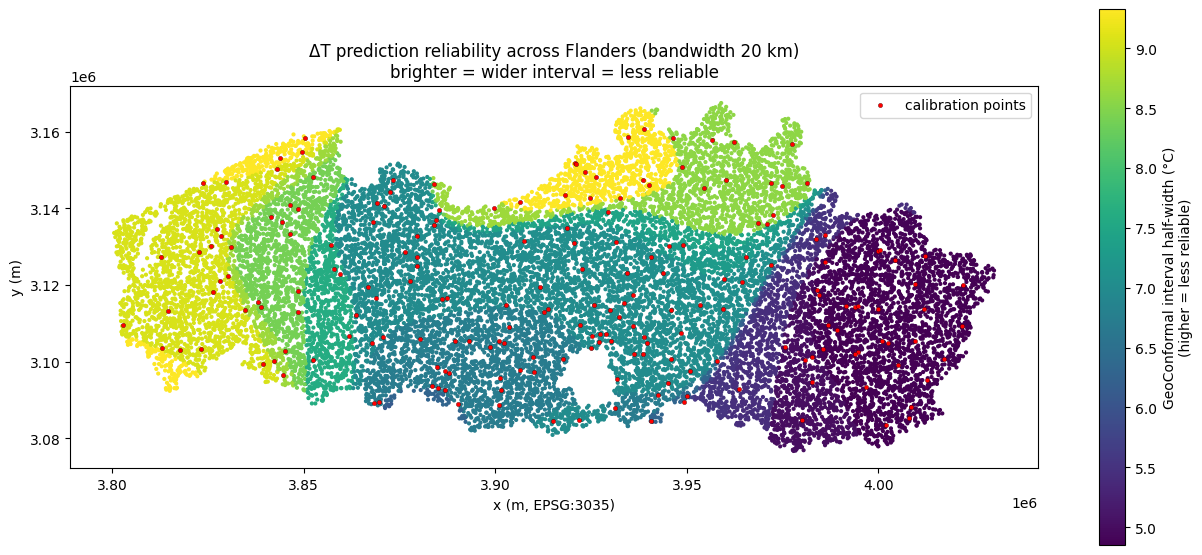

Saved: reliability_map.png


In [42]:
# --- Phase 3c: reliability map over the full grid ---
# Treat every (sub-sampled) grid pixel as a test point and compute its geo half-width
# against the CALIBRATION set. We subsample the grid for tractability (the geo loop is O(pixels × calib)).
import numpy as np

# Build complete-case grid cube -> long table of pixels (reuse Phase-1 logic)
cube_df = (xr.Dataset({'dT': delta.drop_vars('band', errors='ignore'),
                       'NDVI': ndvi.drop_vars('band', errors='ignore'),
                       'landuse': lc_grid.drop_vars('band', errors='ignore')})
           .to_dataframe().reset_index().dropna())

# Subsample grid pixels for the map (e.g. 20k points) to keep the loop fast
grid = cube_df.sample(n=min(20000, len(cube_df)), random_state=1).reset_index(drop=True)

# Build features identically to training (NDVI + land-use dummies, DEM excluded)
grid_enc = pd.get_dummies(grid, columns=['landuse'], prefix='lu', drop_first=True)
for col in feature_cols:                      # ensure all training dummy cols exist
    if col not in grid_enc: grid_enc[col] = 0.0
Xg = grid_enc[feature_cols].astype(float).values
cg = grid[['x','y']].values

# Geo half-width at each grid pixel, against the CALIBRATION residuals
gmap = GeoConformalSpatialRegression(
    predict_f=rf.predict, miscoverage_level=0.1, bandwidth=BW,
    coord_calib=c_cal, coord_test=cg,
    X_calib=X_cal, y_calib=y_cal, X_test=Xg, y_test=np.zeros(len(Xg)))  # y_test unused for the map
gmap.predict_geoconformal_uncertainty()
half = gmap.geo_uncertainty.copy()

# GUARD: pixels far from all calibration points -> weights underflow -> NaN. Mask them.
from scipy.spatial import cKDTree
dist_to_calib = cKDTree(c_cal).query(cg, k=1)[0]
far = (dist_to_calib > 3*BW) | ~np.isfinite(half)
half[far] = np.nan
print(f'Pixels flagged as out-of-support (>3×bw from any calib point): {far.sum()} of {len(half)}')

# --- Plot: reliability map + calibration points ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13,7))
sc = ax.scatter(cg[:,0], cg[:,1], c=half, s=4, cmap='viridis',
                vmin=np.nanpercentile(half,2), vmax=np.nanpercentile(half,98))
ax.scatter(c_cal[:,0], c_cal[:,1], s=10, c='red', edgecolor='k', linewidth=0.2,
           label='calibration points')
plt.colorbar(sc, label='GeoConformal interval half-width (°C)\n(higher = less reliable)', shrink=0.8)
ax.set_title(f'ΔT prediction reliability across Flanders (bandwidth {BW//1000} km)\n'
             'brighter = wider interval = less reliable')
ax.set_xlabel('x (m, EPSG:3035)'); ax.set_ylabel('y (m)')
ax.set_aspect('equal'); ax.legend(loc='upper right')
plt.tight_layout(); plt.savefig(f'{BASE}/reliability_map.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: reliability_map.png')

In [43]:
# --- Why is the west less reliable? Check residual magnitude vs longitude & land use ---
import numpy as np
pred_all = rf.predict(X)                      # all 1000 points
abs_resid = np.abs(pred_all - y)
import pandas as pd
chk = pd.DataFrame({'x': coords[:,0], 'abs_resid': abs_resid,
                    'landuse': df['landuse'].values})
# West vs East split at median x
med_x = np.median(coords[:,0])
print('Median |residual| — West vs East:')
print(f'  West (x < {med_x:.0f}): {chk[chk.x<med_x].abs_resid.median():.2f} °C')
print(f'  East (x >= {med_x:.0f}): {chk[chk.x>=med_x].abs_resid.median():.2f} °C')
print('\nCorrelation |residual| ~ x:', f'{np.corrcoef(chk.x, chk.abs_resid)[0,1]:+.3f}')
print('\nLand-use composition West vs East (share %):')
for side,name in [(chk.x<med_x,'West'),(chk.x>=med_x,'East')]:
    sh = chk[side].landuse.value_counts(normalize=True).sort_index()*100
    print(f'  {name}: ' + ' '.join(f'{int(k)}:{v:.0f}%' for k,v in sh.items()))

Median |residual| — West vs East:
  West (x < 3925250): 1.39 °C
  East (x >= 3925250): 1.38 °C

Correlation |residual| ~ x: -0.034

Land-use composition West vs East (share %):
  West: 1:66% 2:21% 3:9% 4:2% 5:3%
  East: 1:68% 2:13% 3:16% 4:1% 5:3%


In [44]:
# --- Why does the reliability map show a W-E gradient if residuals are spatially uniform? ---
import numpy as np, pandas as pd
pred_all = rf.predict(X); abs_resid = np.abs(pred_all - y)
med_x = np.median(coords[:,0])

# Focus on CALIBRATION residuals (those are what GeoCP weights), not all points
cal_resid = np.abs(rf.predict(X_cal) - y_cal)
west = c_cal[:,0] < med_x
print('CALIBRATION residuals — west vs east:')
print(f'  West: median {np.median(cal_resid[west]):.2f}  90th-pctile {np.percentile(cal_resid[west],90):.2f}  n={west.sum()}')
print(f'  East: median {np.median(cal_resid[~west]):.2f}  90th-pctile {np.percentile(cal_resid[~west],90):.2f}  n={(~west).sum()}')
print(f'  West max residual: {cal_resid[west].max():.2f} | East max: {cal_resid[~west].max():.2f}')
print(f'\nCalibration point count: West {west.sum()} vs East {(~west).sum()}')

CALIBRATION residuals — west vs east:
  West: median 2.50  90th-pctile 7.56  n=103
  East: median 2.66  90th-pctile 5.81  n=97
  West max residual: 10.46 | East max: 11.68

Calibration point count: West 103 vs East 97


### Interpreting the Reliability Map: A methodological caution

The reliability map shows a clear west-east gradient in interval width, which
invites a physical interpretation (e.g. maritime influence in the west making ΔT
harder to predict). Checking the residuals directly **refutes** this:

- Model error is spatially uniform: median |residual| = 1.39 °C (west) vs 1.38 °C
  (east); correlation with longitude ≈ 0.
- Calibration density is balanced: 103 (west) vs 97 (east) points.
- Yet the **90th percentile** of calibration residuals differs: 7.56 °C (west) vs
  5.81 °C (east), despite near-identical medians.

The gradient therefore reflects the **GeoConformal mechanism itself**, not a
physical reliability pattern. GeoConformal sizes intervals from the
distance-weighted 90th percentile of calibration residuals, and that quantile is
sensitive to the *tail* of the local residual distribution. A neighbourhood with a heavier residual tail inherits wider intervals, even when its typical (median) error is normal.

**Takeaway:** a GeoConformal reliability map is a map of the spatial structure of
calibration-residual tails, not necessarily of physical reliability. The two must
be cross-checked before the map is interpreted.

## Findings & Conclusion

1. **A predictor that looked physical was a spatial proxy.** DEM received high
   importance (0.32) but correlated r = -0.61 with latitude in this flat region.
   It was removed to keep the baseline model aspatial, so that all
   spatial signal enters through GeoConformal rather than leaking through a feature.

2. **Low R² is appropriate here** With surface predictors alone the
   model explains 7% of ΔT variance (R² = 0.07). This is expected at 100 m, where
   much of ΔT stems from sub-pixel surface detail and the coarse (9 km) ERA5
   support. A model with substantial, spatially-structured error is what
   makes uncertainty quantification interesting.

3. **GeoConformal validates and adapts.** At a 20 km bandwidth, empirical coverage
   is 0.90 (target 0.90). Interval half-width varies 4.5-9.8 °C across space versus
   a flat 7.0 °C for ordinary CP, same average coverage, redistributed spatially.

4. **A reliability map is not necessarily a physical map.** The west-east gradient
   reflects the spatial structure of calibration-residual *tails*, not a physical
   reliability difference (see methodological caution above).  

  
**Limitations.**  

Complete-case (AND) masking removes 37 % of pixels, concentrated
where LST coverage is "gappy". ΔT mixes a 30 m satellite signal with a block-constant
9 km reanalysis baseline, so within-city ΔT variation largely tracks LST structure, a support-mismatch that is itself a representativeness problem.

**Future work.**  

Add physically-motivated surface predictors (albedo, NDWI) to test
whether richer features absorb the residual-tail structure; replace the coarse ERA5
baseline with near-surface logger measurements; and extend from purely spatial to
spatiotemporal conformal weighting.

**Data & methods.**  
Landsat 8/9 C2L2 and Copernicus DEM (Google Earth Engine);
ERA5-Land 2 m temperature, warm-season 09:00 UTC (Copernicus CDS); Landgebruik
Vlaanderen 2022 land use. GeoConformal via the `geoconformal` package.

### References
- Lou, X., Luo, P., & Meng, L. (2025). GeoConformal Prediction: A Model-Agnostic Framework for Measuring the Uncertainty of Spatial Prediction. Annals of the American Association of Geographers, 115(8), 1971–1998. https://doi.org/10.1080/24694452.2025.2516091
- Angelopoulos AN, Bates S (2023), "Conformal Prediction: A Gentle Introduction". Foundations and Trends in Machine Learning, Vol. 16 No. 4 pp. 494–591, doi: https://doi.org/10.1561/2200000101.
- Tobler, W. R. (1970). A Computer Movie Simulating Urban Growth in the Detroit Region. Economic Geography, 46, 234–240. https://doi.org/10.2307/143141
- Haesen, S., Lembrechts, J. J., De Frenne, P., Lenoir, J., Aalto, J., Ashcroft, M. B., Kopecký, M., Luoto, M., Maclean, I., Nijs, I., Niittynen, P., van den Hoogen, J., Arriga, N., Brůna, J., Buchmann, N., Čiliak, M., Collalti, A., De Lombaerde, E., Descombes, P. … Van Meerbeek, K. (2023). ForestClim—Bioclimatic variables for microclimate temperatures of European forests. Global Change Biology, 29, 2886–2892. https://doi.org/10.1111/gcb.16678
- Copernicus Climate Change Service (C3S)(2019): ERA5-Land hourly data from 1950 to present. Copernicus Climate Change Service (C3S) Climate Data Store (CDS).  https://doi.org/10.24381/cds.e2161bac